In [2]:
# Install required libraries if not installed
# pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree


In [3]:
# Load Titanic dataset (train.csv)
df = pd.read_csv("Titanic-Dataset.csv")

In [4]:
# Quick overview
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum() # check missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Handle Missing Values using .loc

In [7]:
df['Age'].median()

np.float64(28.0)

In [8]:
# Fill missing Age with median using loc
df.loc[df['Age'].isnull(), 'Age']=28.0

In [9]:
# or you can direclty used
# Fill missing Age with median using loc
df.loc[df['Age'].isnull(), 'Age'] = df['Age'].median()

In [10]:
# check age columns only
df["Age"].isnull().sum()

np.int64(0)

In [11]:
# or you can even use 
df.loc[df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [12]:
# for test whole 
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,False,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
df.loc[:,"Embarked"].mode()

0    S
Name: Embarked, dtype: object

In [15]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: object

In [16]:
# Fill missing Embarked with mode using loc
df.loc[df['Embarked'].isnull(), 'Embarked']="s"

In [17]:
# Fill missing Embarked with mode using loc
df.loc[df['Embarked'].isnull(), 'Embarked'] = df['Embarked'].mode()[0]

In [18]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [19]:
df.drop(columns="Cabin",inplace=True)

In [20]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [21]:
# Family size: SibSp + Parch + 1
df.loc[:, 'FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [22]:
df.loc[:, 'IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1
# IsAlone: 1 if single, 0 if with family


In [23]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1


In [24]:
# Extract Title from Name
df.loc[:, 'Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
df["Title"]

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: object

In [25]:
# Simplify rare titles
rare_titles = ['Lady', 'Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']


In [26]:
df["Title"].mode()

0    Mr
Name: Title, dtype: object

In [27]:
df.loc[df['Title'].isin(rare_titles), 'Title'] = 'Rare'
df.loc[df['Title'].isin(['Mlle', 'Ms']), 'Title'] = 'Miss'
df.loc[df['Title'] == 'Mme', 'Title'] = 'Mrs'

In [28]:
# One-hot encoding for categorical features
df = pd.get_dummies(df, columns=['Sex','Embarked','Title'], drop_first=True)


In [29]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Embarked_s,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,0,True,False,True,False,False,True,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,0,False,False,False,False,False,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,1,False,False,True,False,True,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,0,False,False,True,False,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,1,True,False,True,False,False,True,False,False,False


In [30]:
# Features and target
X = df.drop(['PassengerId','Name','Ticket','Survived'], axis=1)
y = df['Survived']

In [31]:
X

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Embarked_s,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,3,22.0,1,0,7.2500,2,0,True,False,True,False,False,True,False,False,False
1,1,38.0,1,0,71.2833,2,0,False,False,False,False,False,False,True,False,False
2,3,26.0,0,0,7.9250,1,1,False,False,True,False,True,False,False,False,False
3,1,35.0,1,0,53.1000,2,0,False,False,True,False,False,False,True,False,False
4,3,35.0,0,0,8.0500,1,1,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,1,1,True,False,True,False,False,False,False,True,False
887,1,19.0,0,0,30.0000,1,1,False,False,True,False,True,False,False,False,False
888,3,28.0,1,2,23.4500,4,0,False,False,True,False,True,False,False,False,False
889,1,26.0,0,0,30.0000,1,1,True,False,False,False,False,True,False,False,False


In [32]:
# Split dataset 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
# Initialize Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred = dt_model.predict(X_test)


In [34]:
y_pred 

array([0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

In [35]:
# Accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7877094972067039
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       105
           1       0.74      0.76      0.75        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



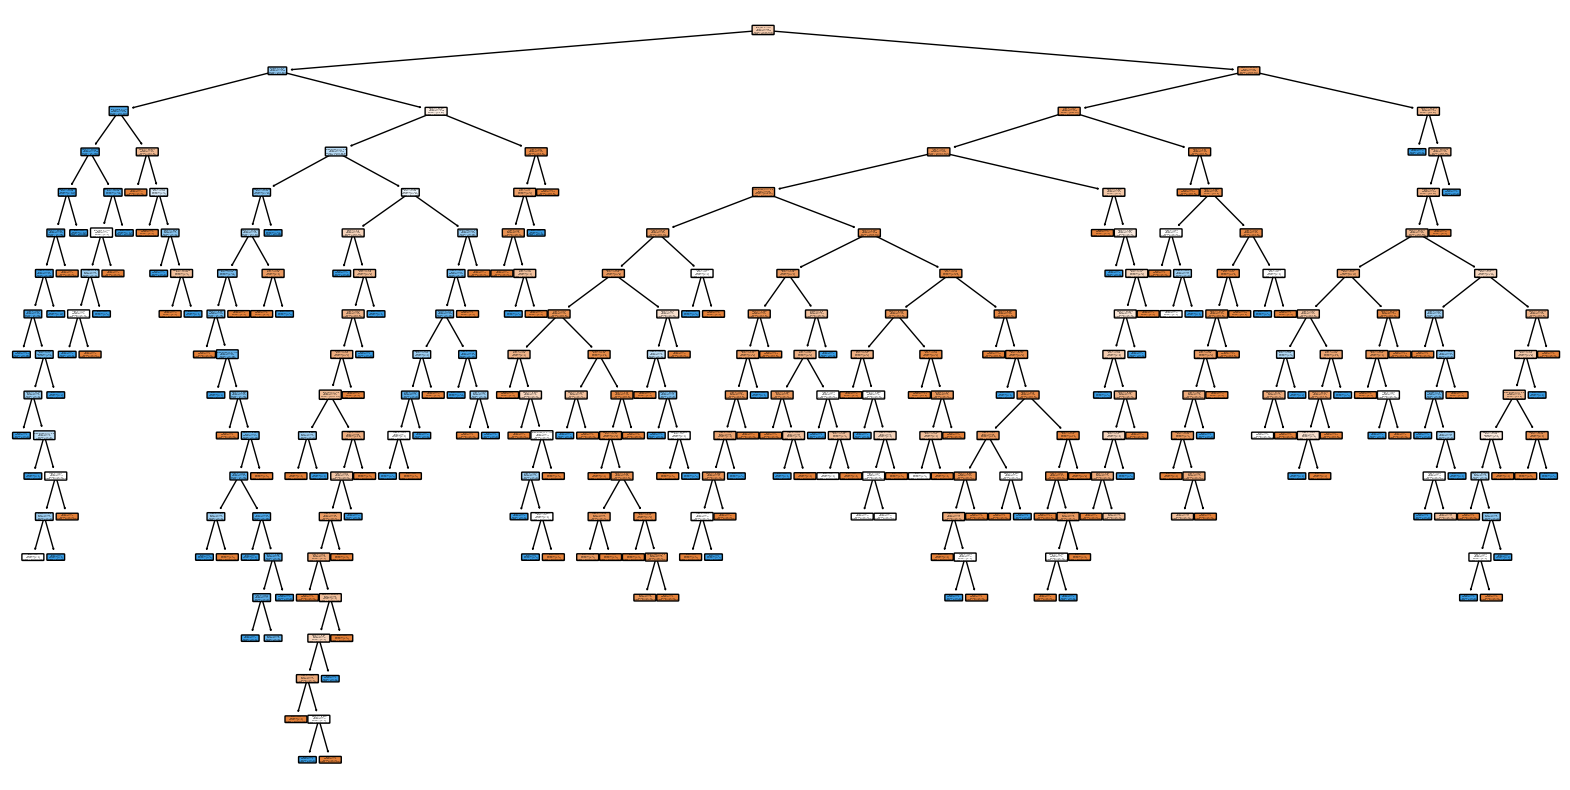

In [36]:
plt.figure(figsize=(20,10))
tree.plot_tree(dt_model, feature_names=X.columns, class_names=['Not Survived','Survived'], filled=True, rounded=True)
plt.show()


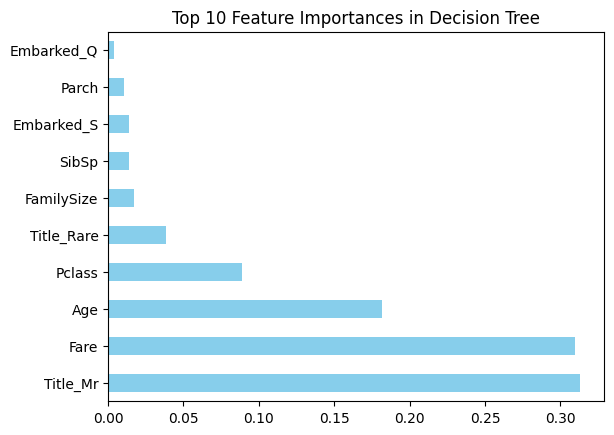

In [37]:
feat_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Feature Importances in Decision Tree")
plt.show()


In [38]:
X_test

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Embarked_s,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
709,3,28.0,1,1,15.2458,3,0,True,False,False,False,False,False,False,False,False
439,2,31.0,0,0,10.5000,1,1,True,False,True,False,False,True,False,False,False
840,3,20.0,0,0,7.9250,1,1,True,False,True,False,False,True,False,False,False
720,2,6.0,0,1,33.0000,2,0,False,False,True,False,True,False,False,False,False
39,3,14.0,1,0,11.2417,2,0,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,3,17.0,0,0,7.1250,1,1,True,False,True,False,False,True,False,False,False
773,3,28.0,0,0,7.2250,1,1,True,False,False,False,False,True,False,False,False
25,3,38.0,1,5,31.3875,7,0,False,False,True,False,False,False,True,False,False
84,2,17.0,0,0,10.5000,1,1,False,False,True,False,True,False,False,False,False


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.8324022346368715


In [41]:
X_test

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Embarked_s,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
709,3,28.0,1,1,15.2458,3,0,True,False,False,False,False,False,False,False,False
439,2,31.0,0,0,10.5000,1,1,True,False,True,False,False,True,False,False,False
840,3,20.0,0,0,7.9250,1,1,True,False,True,False,False,True,False,False,False
720,2,6.0,0,1,33.0000,2,0,False,False,True,False,True,False,False,False,False
39,3,14.0,1,0,11.2417,2,0,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,3,17.0,0,0,7.1250,1,1,True,False,True,False,False,True,False,False,False
773,3,28.0,0,0,7.2250,1,1,True,False,False,False,False,True,False,False,False
25,3,38.0,1,5,31.3875,7,0,False,False,True,False,False,False,True,False,False
84,2,17.0,0,0,10.5000,1,1,False,False,True,False,True,False,False,False,False


In [40]:
import joblib

# Save the trained Decision Tree model
joblib.dump(dt_model, "titanic_decision_tree.pkl")

# Later, you can load it like this:
# loaded_model = joblib.load("titanic_decision_tree.pkl")


['titanic_decision_tree.pkl']

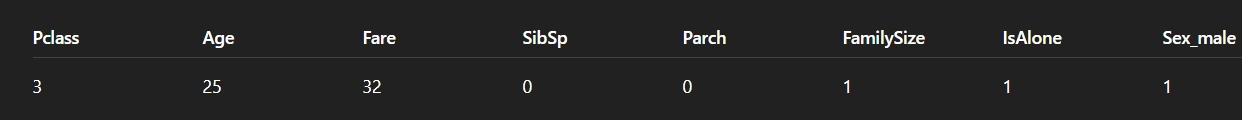

In [44]:
from PIL import Image
from IPython.display import display

img = Image.open("img1.jpg")
display(img)

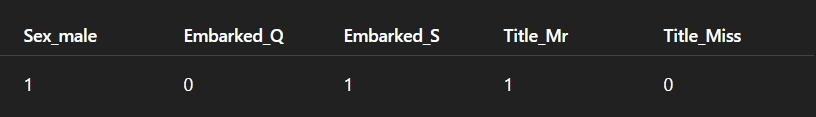

In [43]:
from PIL import Image
from IPython.display import display

img = Image.open("img.jpg")
display(img)